<a href="https://colab.research.google.com/github/andrewprayle/Ark-xray-fork/blob/main/2025_07_06c_automated_search_working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated search

Automated Literature Search with LLM-Based Screening

This script implements a semi-automated literature search pipeline that combines:
- PubMed for biomedical literature search
- Semantic Scholar for citation network analysis
- Large Language Models for automated abstract screening

Features:
- Automated paper discovery and screening
- Citation network visualization
- Configurable inclusion criteria
- Robust error handling and logging

Use Case:
This pipeline is designed for systematic literature reviews, particularly in medical
research.

Author: Refactored from original notebook
Date: December 2024
Version: 0.1

Todo:

- Update to use Mistral 24B I have this working on the other side.  
- Change the flow of data so only the LLM included papers stay in the citation network
- Check that each paper is LLM'd only once - after we've got the list of dois from the semantic scholar we may have multiple ones.  


Done
- search pubmed for a list of relevant ids identify an index pubmed id
- download the relevant abstract and information
- save a pubmed id
- identify citations contained within the pubmed record - DONE
- update a spreadsheet of citing articles
- identrify  a list of citations of the index
- make a network graph



# Notes on how this notebook works

This is refactored code from the 2024-12 version

In the pairs, we should go

article1 -> article2

indicates that article2 cites article1 (i.e. article2 builds on article1), article2 is later in time.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install Bio
!pip install xmltodict
!pip install bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:

# =============================================================================
# 1. IMPORTS AND DEPENDENCIES
# =============================================================================

# Core imports
import os
import pandas as pd
import numpy as np
import requests
import logging
import time
import json
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass
from datetime import datetime

# Biomedical data imports
from Bio import Entrez
import xmltodict
import xml.etree.ElementTree as ET

# Machine learning imports - we may need to specify specific versions as
# we move to Minstral 24B
import transformers
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Visualization
import networkx as nx
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# hash libaries for the deduplication
import hashlib
from difflib import SequenceMatcher

print("✅ All dependencies imported successfully!")



✅ All dependencies imported successfully!


In [ ]:
# =============================================================================
# 2. CONFIGURATION CLASS
# =============================================================================

@dataclass
class Config:
    """Configuration settings for the literature search pipeline

    Modify these settings to customize the pipeline for your needs.
    """
    # API Settings - Replace with your own credentials
    entrez_email: str = "andrew.prayle@nottingham.ac.uk"  # Required for PubMed API
    semantic_scholar_api_key: str = "tQQnYzdIRN9uU77tHFOPc4kgJnA8zZCa1p1I7H6n"  # Optional but recommended
    # tQQnYzdIRN9uU77tHFOPc4kgJnA8zZCa1p1I7H6n

    # Model Settings
    model_id: str = "hugging-quants/Meta-Llama-3.1-8B-Instruct-BNB-NF4"
    max_tokens: int = 256

    # Search Settings
    max_search_results: int = 200  # Number of papers to retrieve from initial search
    citation_limit: int = 50      # Max citations per paper to analyze
    rate_limit_delay: float = 5.0 # Delay between API calls (seconds)

    # File paths
    log_file: str = "literature_search.log"
    results_file: str = "search_results.csv"

    # Citation screening settings
    screen_discovered_citations: bool = True  # Whether to LLM screen papers found via citations
    max_discovered_to_screen: int = 200        # Limit on discovered papers to screen (to control costs)

# Initialize configuration
config = Config()

print("✅ Configuration loaded successfully!")
print(f"📊 Will search for up to {config.max_search_results} papers")
print(f"🤖 Using model: {config.model_id}")

✅ Configuration loaded successfully!
📊 Will search for up to 200 papers
🤖 Using model: hugging-quants/Meta-Llama-3.1-8B-Instruct-BNB-NF4


In [ ]:
# =============================================================================
# 3. LOGGING SETUP
# =============================================================================

def setup_logging(log_file: str = None) -> logging.Logger:
    """Setup comprehensive logging for the pipeline"""
    log_file = log_file or config.log_file

    # Create logger
    logger = logging.getLogger('literature_search')
    logger.setLevel(logging.INFO)

    # Clear existing handlers to avoid duplicates
    logger.handlers = []

    # Create formatters
    formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
    )

    # Console handler for immediate feedback
    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    # File handler for persistent logging
    file_handler = logging.FileHandler(log_file)
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    return logger

# Initialize logger
logger = setup_logging()
logger.info("🚀 Literature search pipeline starting up...")



2025-07-07 21:47:42,641 - literature_search - INFO - 🚀 Literature search pipeline starting up...
INFO:literature_search:🚀 Literature search pipeline starting up...


In [ ]:
# =============================================================================
# 4. UTILITY FUNCTIONS
# =============================================================================

def debug_citation_analysis(pipeline):
    """Debug function to check why citation analysis might be failing"""
    print("\n🔍 DEBUGGING CITATION ANALYSIS")
    print("=" * 40)

    # Check included papers
    if not pipeline.screening_results.empty:
        included_papers = pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']
        print(f"📊 Included papers: {len(included_papers)}")

        # Check DOIs
        papers_with_doi = included_papers[included_papers['doi'] != 'No DOI']
        print(f"📄 Included papers with DOI: {len(papers_with_doi)}")

        if not papers_with_doi.empty:
            print("\n📋 DOIs of included papers:")
            for idx, (_, paper) in enumerate(papers_with_doi.iterrows(), 1):
                clean_doi_val = clean_doi(paper['doi'])
                print(f"   {idx}. PMID {paper['pmid']}: {clean_doi_val}")

        # Check config
        print(f"\n⚙️ Configuration:")
        print(f"   screen_discovered_citations: {getattr(pipeline.config, 'screen_discovered_citations', 'NOT SET')}")
        print(f"   max_discovered_to_screen: {getattr(pipeline.config, 'max_discovered_to_screen', 'NOT SET')}")
        print(f"   citation_limit: {pipeline.config.citation_limit}")

        # Test one DOI manually if available
        if not papers_with_doi.empty:
            test_doi = clean_doi(papers_with_doi.iloc[0]['doi'])
            print(f"\n🧪 Testing citation lookup for: {test_doi}")

            try:
                citing_papers = pipeline.semantic_scholar.get_citations(test_doi, 3)
                if citing_papers is not None:
                    print(f"   ✅ Found citing papers: {len(citing_papers)}")
                    if 'DOI' in citing_papers.columns:
                        valid_dois = citing_papers['DOI'].dropna()
                        print(f"   ✅ Valid DOIs: {len(valid_dois)}")
                    else:
                        print(f"   ⚠️ No DOI column in results")
                else:
                    print(f"   ❌ No citing papers found")

                ref_papers = pipeline.semantic_scholar.get_references(test_doi, 3)
                if ref_papers is not None:
                    print(f"   ✅ Found referenced papers: {len(ref_papers)}")
                else:
                    print(f"   ❌ No referenced papers found")

            except Exception as e:
                print(f"   ❌ Error testing citation lookup: {e}")
    else:
        print("❌ No screening results available")

def clean_text(text: str) -> str:
    """Remove special characters and clean text for processing"""
    if not isinstance(text, str):
        return str(text)

    special_chars = ['\r', '\n', '\t', '[', ']']
    for char in special_chars:
        text = text.replace(char, ' ')

    # Remove extra whitespace
    return ' '.join(text.split())

def extract_json_from_string(input_string: str) -> str:
    """Extract JSON object from string response"""
    start_index = input_string.find('{')
    end_index = input_string.rfind('}')

    if start_index != -1 and end_index != -1:
        return input_string[start_index:end_index + 1]
    return "No JSON"

def clean_doi(doi_string: str) -> str:
    """Clean DOI string by removing URL prefix"""
    if not isinstance(doi_string, str):
        return str(doi_string)

    prefix = "https://dx.doi.org/"
    if doi_string.startswith(prefix):
        return doi_string[len(prefix):]
    return doi_string

def safe_api_call(func, *args, max_retries=3, delay=1.0, **kwargs):
    """Wrapper for API calls with retry logic and rate limiting"""
    for attempt in range(max_retries):
        try:
            result = func(*args, **kwargs)
            if delay > 0:
                time.sleep(delay)
            return result
        except Exception as e:
            logger.warning(f"API call failed (attempt {attempt + 1}): {e}")
            if attempt == max_retries - 1:
                raise
            time.sleep(delay * (attempt + 1))



print("✅ Utility functions loaded successfully!")

# Deduplication class:

class PaperDeduplicator:
    """Handle deduplication of papers from multiple sources"""

    def __init__(self):
        self.logger = logging.getLogger('literature_search')

    def normalize_title(self, title: str) -> str:
        """Normalize title for comparison"""
        if not isinstance(title, str):
            return ""

        # Convert to lowercase
        title = title.lower()

        # Remove common punctuation and special characters
        title = re.sub(r'[^\w\s]', ' ', title)

        # Remove extra whitespace
        title = ' '.join(title.split())

        # Remove common stop words that don't affect uniqueness
        stop_words = ['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by']
        words = title.split()
        title = ' '.join([word for word in words if word not in stop_words])

        return title.strip()

    def normalize_doi(self, doi: str) -> str:
        """Normalize DOI for comparison"""
        if not isinstance(doi, str) or doi == "No DOI":
            return ""

        # Remove common prefixes
        doi = doi.lower()
        prefixes = ['https://doi.org/', 'https://dx.doi.org/', 'doi:', 'http://dx.doi.org/']

        for prefix in prefixes:
            if doi.startswith(prefix):
                doi = doi[len(prefix):]
                break

        return doi.strip()

    def calculate_title_similarity(self, title1: str, title2: str) -> float:
        """Calculate similarity between two titles"""
        norm_title1 = self.normalize_title(title1)
        norm_title2 = self.normalize_title(title2)

        if not norm_title1 or not norm_title2:
            return 0.0

        return SequenceMatcher(None, norm_title1, norm_title2).ratio()

    def create_paper_fingerprint(self, row) -> str:
        """Create a unique fingerprint for a paper"""
        # Use DOI if available, otherwise use normalized title + year + first author
        doi = self.normalize_doi(row.get('doi', ''))
        if doi:
            return f"doi:{doi}"

        title = self.normalize_title(row.get('title', ''))
        year = str(row.get('year', 'unknown'))
        author = str(row.get('author', 'unknown')).lower()

        # Create hash of combined info
        combined = f"{title}_{year}_{author}"
        return hashlib.md5(combined.encode()).hexdigest()[:16]

    def deduplicate_papers(self, papers_df: pd.DataFrame, similarity_threshold: float = 0.9) -> pd.DataFrame:
        """
        Remove duplicate papers from DataFrame

        Args:
            papers_df: DataFrame containing papers
            similarity_threshold: Threshold for title similarity (0.0-1.0)

        Returns:
            DataFrame with duplicates removed
        """
        if papers_df.empty:
            return papers_df

        self.logger.info(f"🔄 Starting deduplication of {len(papers_df)} papers")

        # Step 1: Remove exact DOI duplicates (fastest)
        initial_count = len(papers_df)

        # Get papers with valid DOIs
        papers_with_doi = papers_df[papers_df['doi'] != 'No DOI'].copy()
        papers_without_doi = papers_df[papers_df['doi'] == 'No DOI'].copy()

        if not papers_with_doi.empty:
            # Normalize DOIs and remove duplicates
            papers_with_doi['normalized_doi'] = papers_with_doi['doi'].apply(self.normalize_doi)
            papers_with_doi = papers_with_doi.drop_duplicates(subset=['normalized_doi'], keep='first')
            papers_with_doi = papers_with_doi.drop('normalized_doi', axis=1)

            doi_removed = initial_count - len(papers_with_doi) - len(papers_without_doi)
            if doi_removed > 0:
                self.logger.info(f"   ✅ Removed {doi_removed} exact DOI duplicates")

        # Step 2: Create fingerprints for remaining papers
        all_papers = pd.concat([papers_with_doi, papers_without_doi], ignore_index=True)
        all_papers['fingerprint'] = all_papers.apply(self.create_paper_fingerprint, axis=1)

        # Remove fingerprint duplicates
        before_fingerprint = len(all_papers)
        all_papers = all_papers.drop_duplicates(subset=['fingerprint'], keep='first')
        fingerprint_removed = before_fingerprint - len(all_papers)

        if fingerprint_removed > 0:
            self.logger.info(f"   ✅ Removed {fingerprint_removed} fingerprint duplicates")

        # Step 3: Title similarity deduplication (most thorough but slowest)
        unique_papers = []
        processed_indices = set()

        for i, (idx1, paper1) in enumerate(all_papers.iterrows()):
            if idx1 in processed_indices:
                continue

            # This paper hasn't been marked as duplicate
            is_unique = True

            # Compare with remaining papers
            for idx2, paper2 in all_papers.iloc[i+1:].iterrows():
                if idx2 in processed_indices:
                    continue

                # Skip if different DOIs (both valid)
                doi1 = self.normalize_doi(paper1.get('doi', ''))
                doi2 = self.normalize_doi(paper2.get('doi', ''))
                if doi1 and doi2 and doi1 != doi2:
                    continue

                # Calculate title similarity
                similarity = self.calculate_title_similarity(
                    paper1.get('title', ''),
                    paper2.get('title', '')
                )

                if similarity >= similarity_threshold:
                    # Mark the second paper as duplicate
                    processed_indices.add(idx2)
                    self.logger.debug(f"   📝 Found similar titles (similarity: {similarity:.3f})")
                    self.logger.debug(f"      Paper 1: {paper1.get('title', '')[:60]}...")
                    self.logger.debug(f"      Paper 2: {paper2.get('title', '')[:60]}...")

            if is_unique:
                unique_papers.append(paper1)
                processed_indices.add(idx1)

        # Create final DataFrame
        result_df = pd.DataFrame(unique_papers)
        result_df = result_df.drop('fingerprint', axis=1)  # Remove helper column

        title_removed = len(all_papers) - len(result_df)
        if title_removed > 0:
            self.logger.info(f"   ✅ Removed {title_removed} title similarity duplicates")

        total_removed = initial_count - len(result_df)
        self.logger.info(f"🎯 Deduplication complete: removed {total_removed} duplicates ({len(result_df)} unique papers remaining)")

        return result_df

    def merge_paper_data(self, primary_paper: dict, duplicate_paper: dict) -> dict:
        """
        Merge data from duplicate papers, keeping the most complete information
        """
        merged = primary_paper.copy()

        # Prefer non-empty values
        for key in duplicate_paper:
            if key in merged:
                # If primary has empty/missing value but duplicate has value
                if (not merged[key] or merged[key] in ['No DOI', 'Unknown', 'No abstract available']) and duplicate_paper[key]:
                    merged[key] = duplicate_paper[key]

        return merged


✅ Utility functions loaded successfully!


In [ ]:

# =============================================================================
# 5. PUBMED INTERFACE CLASS
# =============================================================================

class PubMedSearcher:
    """Handle PubMed search operations and data extraction"""

    def __init__(self, email: str):
        self.email = email
        Entrez.email = email
        logger.info(f"📚 PubMed searcher initialized with email: {email}")

    def search_pubmed(self, query: str, max_results: int = 5) -> List[str]:
        """Search PubMed and return list of PMIDs"""
        try:
            logger.info(f"🔍 Searching PubMed with query: '{query}'")
            search_handle = Entrez.esearch(
                db="pubmed",
                term=query,
                retmax=max_results
            )
            search_results = Entrez.read(search_handle)
            search_handle.close()

            pmids = search_results["IdList"]
            logger.info(f"📄 Found {len(pmids)} papers")
            return pmids

        except Exception as e:
            logger.error(f"❌ PubMed search failed: {e}")
            return []

    def fetch_records(self, pmid_list: List[str]) -> dict:
        """Fetch full records for given PMIDs"""
        try:
            logger.info(f"📥 Fetching {len(pmid_list)} records from PubMed")
            fetch_handle = Entrez.efetch(db="pubmed", id=pmid_list, retmode="xml")
            records = Entrez.read(fetch_handle)
            fetch_handle.close()
            return records
        except Exception as e:
            logger.error(f"❌ Failed to fetch records: {e}")
            return {}

    def extract_paper_data(self, records: dict) -> pd.DataFrame:
        """Extract structured data from PubMed records"""
        data = []

        for record in records.get("PubmedArticle", []):
            try:
                # Extract basic info
                pmid = str(record["MedlineCitation"]["PMID"])
                title = record['MedlineCitation']['Article']['ArticleTitle']

                # Extract DOI
                doi = "No DOI"
                article_data = record.get("PubmedData", {})
                article_ids = article_data.get("ArticleIdList", [])

                for item in article_ids:
                    if hasattr(item, 'attributes') and item.attributes.get("IdType") == "doi":
                        doi = str(item)
                        break

                # Extract author
                authors = record['MedlineCitation']['Article'].get('AuthorList', [])
                first_author = authors[0]['LastName'] if authors else "Unknown"

                # Extract year
                article_date = record['MedlineCitation']['Article'].get('ArticleDate', [])
                year = article_date[0].get('Year', 'Unknown') if article_date else 'Unknown'

                # Extract journal
                journal_info = record['MedlineCitation']['Article']['Journal']
                journal_title = journal_info.get('Title', 'Unknown')

                # Extract abstract with improved handling
                abstract_data = record['MedlineCitation']['Article'].get('Abstract', {})
                abstract_text = abstract_data.get("AbstractText", [])

                if abstract_text:
                    # Handle structured abstracts with labels
                    if (hasattr(abstract_text[0], 'attributes') and
                        'Label' in getattr(abstract_text[0], 'attributes', {})):
                        labels = [item.attributes['Label'] for item in abstract_text]
                        abstract_string = ' '.join([f'{label}: {text}' for label, text in zip(labels, abstract_text)])
                    else:
                        abstract_string = ' '.join(str(item) for item in abstract_text)
                else:
                    abstract_string = "No abstract available"

                data.append({
                    "pmid": pmid,
                    "doi": doi,
                    "title": title,
                    "author": first_author,
                    "year": year,
                    "journal_title": journal_title,
                    "abstract": clean_text(abstract_string)
                })

            except Exception as e:
                logger.warning(f"⚠️ Failed to extract data from record: {e}")
                continue

        logger.info(f"✅ Successfully extracted data from {len(data)} papers")
        return pd.DataFrame(data)

print("✅ PubMed interface class defined successfully!")


✅ PubMed interface class defined successfully!


In [ ]:

# =============================================================================
# 6. SEMANTIC SCHOLAR API CLASS
# =============================================================================

class SemanticScholarAPI:
    """Handle Semantic Scholar API operations for citation analysis"""

    def __init__(self, api_key: str):
        self.api_key = api_key
        self.headers = {'x-api-key': api_key} if api_key != "tQQnYzdIRN9uU77tHFOPc4kgJnA8zZCa1p1I7H6n" else {}
        self.base_url = 'https://api.semanticscholar.org/graph/v1/paper'

        if not self.headers:
            logger.warning("⚠️ No Semantic Scholar API key provided. Rate limits will be more restrictive.")
        else:
            logger.info("🔗 Semantic Scholar API initialized with authentication")

    def get_citations(self, doi: str, limit: int = 10) -> Optional[pd.DataFrame]:
        """Get papers that cite the given DOI"""
        return self._get_related_papers(doi, 'citations', limit)

    def get_references(self, doi: str, limit: int = 10) -> Optional[pd.DataFrame]:
        """Get papers referenced by the given DOI"""
        return self._get_related_papers(doi, 'references', limit)

    def _get_related_papers(self, doi: str, relation_type: str, limit: int) -> Optional[pd.DataFrame]:
        """Generic method to get related papers (citations or references)"""
        doi_id = f"DOI:{doi}"
        url = f'{self.base_url}/{doi_id}/{relation_type}'
        params = {'fields': 'title,year,externalIds', 'limit': limit}

        try:
            logger.info(f"🔍 Getting {relation_type} for DOI: {doi}")

            response = safe_api_call(
                requests.get,
                url,
                params=params,
                headers=self.headers,
                delay=config.rate_limit_delay
            )

            if response.status_code == 200:
                data = response.json()
                if not data.get('data'):
                    logger.info(f"ℹ️ No {relation_type} found for DOI: {doi}")
                    return None

                # Extract paper info
                paper_key = 'citingPaper' if relation_type == 'citations' else 'citedPaper'
                papers = [item[paper_key] for item in data['data']]
                df = pd.DataFrame(papers)

                if 'externalIds' in df.columns:
                    # Normalize externalIds and merge with other columns
                    external_ids_df = pd.json_normalize(df['externalIds'])

                    # Combine with title and year
                    result_df = pd.concat([
                        df[['title', 'year']].reset_index(drop=True),
                        external_ids_df.reset_index(drop=True)
                    ], axis=1)

                    logger.info(f"📊 Found {len(result_df)} {relation_type}")
                    return result_df
                else:
                    # If no externalIds, just return title and year
                    logger.info(f"📊 Found {len(df)} {relation_type} (no DOIs)")
                    return df

            elif response.status_code == 404:
                logger.info(f"ℹ️ Paper not found in Semantic Scholar: {doi}")
            else:
                logger.error(f"❌ Semantic Scholar API error: {response.status_code}")

        except Exception as e:
            logger.error(f"❌ Failed to get {relation_type} for {doi}: {e}")

        return None

print("✅ Semantic Scholar interface class defined successfully!")


✅ Semantic Scholar interface class defined successfully!


In [ ]:
# =============================================================================
# 7. LLM SCREENING CLASS
# =============================================================================

class LLMScreener:
    """Handle LLM-based paper screening with customizable criteria"""

    def __init__(self, model_id: str):
        self.model_id = model_id
        self.tokenizer = None
        self.model = None

    def load_model(self):
        """Load the LLM model and tokenizer"""
        try:
            logger.info(f"🤖 Loading model: {self.model_id}")
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_id,
                torch_dtype=torch.bfloat16,
                low_cpu_mem_usage=True,
                device_map="auto",
            )
            logger.info("✅ Model loaded successfully")
        except Exception as e:
            logger.error(f"❌ Failed to load model: {e}")
            raise

    def get_screening_prompt(self) -> str:
        """Get the standardized screening prompt for clinical research"""
        return '''The context below provides an article title and abstract from the medical literature. You are screening this article abstract to determine if it is suitable for inclusion in a review of the literature.

The inclusion criteria for the abstracts are that the article must describe a clinical research study. If it is a study primarily based in the lab (e.g. a "basic science" study growing cells in a laboratory without direct relevance to individual patients then it should not be included.

The study should also investigate ataxia-telangiectasia  in children, and in some way should recruit children or adults with ataxia telangiectasia.
The result should be returned in JSON format following the following template:

{
    "doi": "123/123",
    "pmid": "34567823",
    "study_type": "observational",
    "includes_correct_patients": "TRUE",
    "included": "TRUE"
}

The "doi" field should contain the study DOI.
The "pmid" field should contain the study PMID.
The study_type should be one of "narrative_review", "systematic_review", "randomised_trial", "quasi_randomised_trial", "non_randomised_trial", "observational_study", "case_series", "case_report", "opinion_piece", "editorial" or "other". A study should only be categorized as a randomised_trial if participants are allocated to groups at random. The includes_correct_patients should be TRUE if the study recruits children or adults with ataxia-telangiectasia.

The "included" field should be TRUE if the study meets the inclusion criteria and FALSE otherwise. If the title suggests that the study could be included, but there is no abstract, then return the value POSSIBLE_NO_ABSTRACT. If the abstract is very short, and it is not possible to determine fully if the study meets the inclusion criteria, assume that the study can be included.
'''

    def create_context(self, pmid: str, doi: str, title: str, abstract: str) -> str:
        """Create context string for LLM processing"""
        return f'PMID: {pmid} DOI: {doi} Title: {title}\n\nAbstract: {clean_text(abstract)}'

    def extract_assistant_response(self, text_list: List[str]) -> str:
        """Extract assistant response from model output"""
        full_text = ' '.join(text_list)
        parts = full_text.split('assistant\n')

        if len(parts) < 2:
            return None

        assistant_response = parts[1]
        next_markers = ['user\n', 'system\n', 'assistant\n']

        for marker in next_markers:
            if marker in assistant_response:
                assistant_response = assistant_response.split(marker)[0]

        return assistant_response.strip()

    def screen_paper(self, pmid: str, doi: str, title: str, abstract: str,
                    max_retries: int = 3) -> Optional[Dict]:
        """Screen a single paper using LLM"""
        if not self.model or not self.tokenizer:
            logger.error("❌ Model not loaded. Call load_model() first.")
            return None

        context = self.create_context(pmid, doi, title, abstract)
        prompt_text = self.get_screening_prompt() + context

        prompt = [
            {"role": "system", "content": "You are a helpful assistant for question-answering tasks. Use only the information provided in the context."},
            {"role": "user", "content": prompt_text}
        ]

        for attempt in range(max_retries):
            try:
                # Generate response
                inputs = self.tokenizer.apply_chat_template(
                    prompt,
                    tokenize=True,
                    add_generation_prompt=True,
                    return_tensors="pt"
                )

                if torch.cuda.is_available():
                    inputs = inputs.cuda()

                outputs = self.model.generate(
                    inputs,
                    do_sample=True,
                    max_new_tokens=config.max_tokens,
                    pad_token_id=self.tokenizer.eos_token_id
                )

                output = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)
                assistant_response = self.extract_assistant_response(output)

                if not assistant_response:
                    logger.warning(f"⚠️ No assistant response found (attempt {attempt + 1})")
                    continue

                # Parse JSON response
                json_str = extract_json_from_string(assistant_response)
                if json_str == "No JSON":
                    logger.warning(f"⚠️ No JSON found in response (attempt {attempt + 1})")
                    continue

                result = json.loads(json_str)

                # Validate response format
                required_fields = ["doi", "pmid", "study_type", "includes_correct_patients", "included"]
                if all(field in result for field in required_fields):
                    logger.info(f"✅ Successfully screened paper {pmid}")
                    return result
                else:
                    logger.warning(f"⚠️ Invalid response format (attempt {attempt + 1})")

            except Exception as e:
                logger.warning(f"⚠️ LLM screening attempt {attempt + 1} failed: {e}")
                continue

        logger.error(f"❌ Failed to screen paper {pmid} after {max_retries} attempts")
        return None

print("✅ LLM screening class defined successfully!")




✅ LLM screening class defined successfully!


In [ ]:

# =============================================================================
# 8. CITATION NETWORK ANALYZER CLASS
# =============================================================================

class CitationNetworkAnalyzer:
    """Handle citation network analysis and visualization"""

    def __init__(self):
        self.graph = nx.DiGraph()  # Directed graph for citations
        logger.info("🕸️ Citation network analyzer initialized")

    def add_citation_edge(self, citing_paper: str, cited_paper: str):
        """Add citation relationship to graph (cited -> citing)"""
        self.graph.add_edge(cited_paper, citing_paper)

    def build_network_from_dataframe(self, df: pd.DataFrame):
        """Build network from DataFrame with 'article1' and 'article2' columns"""
        if df.empty:
            logger.warning("⚠️ Empty DataFrame provided for network building")
            return

        for _, row in df.iterrows():
            # article1 is cited by article2
            self.add_citation_edge(row['article2'], row['article1'])

        logger.info(f"📊 Built citation network with {len(df)} relationships")

    def visualize_network(self, figsize: tuple = (14, 10), save_path: str = None):
        """Create an enhanced visualization of the citation network"""
        if not self.graph.nodes():
            logger.warning("⚠️ No nodes in graph to visualize")
            print("ℹ️ No citation network to display. Try running the pipeline first.")
            return

        plt.figure(figsize=figsize)

        # Calculate node sizes based on degree (more citations = larger node)
        degrees = dict(self.graph.degree())
        node_sizes = [max(200, degrees.get(node, 1) * 100) for node in self.graph.nodes()]

        # Use spring layout with adjusted parameters for better spacing
        pos = nx.spring_layout(self.graph, k=0.5, iterations=50, seed=42)

        # Draw network with enhanced styling
        nx.draw(
            self.graph,
            pos,
            with_labels=False,
            node_size=node_sizes,
            node_color='lightblue',
            edge_color='gray',
            arrows=True,
            arrowsize=20,
            alpha=0.7,
            width=0.5
        )

        # Add labels with smart positioning to avoid overlap
        labels = {}
        for node in self.graph.nodes:
            # Truncate long DOIs for readability
            display_label = node[:15] + "..." if len(node) > 15 else node
            labels[node] = display_label

        # Draw labels with offset
        label_pos = {node: (pos[node][0], pos[node][1] + 0.05) for node in pos}
        nx.draw_networkx_labels(self.graph, label_pos, labels, font_size=8, font_weight='bold')

        # Add title and formatting
        plt.title("Citation Network Analysis\n(Node size indicates citation count)",
                 fontsize=16, fontweight='bold', pad=20)
        plt.axis('off')

        # Add network statistics as text
        stats = self.get_network_stats()
        stats_text = f"Nodes: {stats['num_nodes']} | Edges: {stats['num_edges']} | Density: {stats['density']:.3f}"
        plt.figtext(0.5, 0.02, stats_text, ha='center', fontsize=10)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"💾 Network visualization saved to {save_path}")

        plt.tight_layout()
        plt.show()

    def get_network_stats(self) -> Dict:
        """Calculate and return network statistics"""
        if not self.graph.nodes():
            return {'num_nodes': 0, 'num_edges': 0, 'density': 0, 'is_connected': False}

        stats = {
            'num_nodes': int(self.graph.number_of_nodes()),      # ← ADD int()
            'num_edges': int(self.graph.number_of_edges()),      # ← ADD int()
            'density': float(nx.density(self.graph)),            # ← ADD float()
            'is_connected': nx.is_weakly_connected(self.graph)
        }

        # Add degree statistics
        degrees = [d for n, d in self.graph.degree()]
        if degrees:
            stats.update({
                'avg_degree': float(np.mean(degrees)),   # ← ADD float()
                'max_degree': int(np.max(degrees)),      # ← ADD int()
                'min_degree': int(np.min(degrees))       # ← ADD int()
            })

        return stats

    def find_influential_papers(self, top_n: int = 5) -> List[Tuple[str, int]]:
        """Find the most cited papers in the network"""
        if not self.graph.nodes():
            return []

        # Get in-degree (number of times cited)
        in_degrees = self.graph.in_degree()
        sorted_papers = sorted(in_degrees, key=lambda x: x[1], reverse=True)

        return sorted_papers[:top_n]

print("✅ Citation network analyzer class defined successfully!")



✅ Citation network analyzer class defined successfully!


In [ ]:
# =============================================================================
# 9. MAIN PIPELINE CLASS
# =============================================================================

class LiteratureSearchPipeline:
    """Main pipeline orchestrating the literature search process"""

    def __init__(self, config: Config):
        self.config = config

        # Initialize components
        self.pubmed = PubMedSearcher(config.entrez_email)
        self.semantic_scholar = SemanticScholarAPI(config.semantic_scholar_api_key)
        self.llm_screener = LLMScreener(config.model_id)
        self.network_analyzer = CitationNetworkAnalyzer()

        # Results storage
        self.search_results = pd.DataFrame()
        self.screening_results = pd.DataFrame()
        self.citation_network = pd.DataFrame()

        logger.info("🎯 Literature search pipeline initialized")

    def search_literature(self, query: str) -> pd.DataFrame:
        """Perform initial literature search in PubMed"""
        logger.info("=== STEP 1: LITERATURE SEARCH ===")
        logger.info(f"🔍 Searching with query: {query}")

        # Search PubMed
        pmid_list = self.pubmed.search_pubmed(query, self.config.max_search_results)

        if not pmid_list:
            logger.warning("⚠️ No results found in PubMed")
            return pd.DataFrame()

        # Fetch full records
        records = self.pubmed.fetch_records(pmid_list)

        # Extract structured data
        self.search_results = self.pubmed.extract_paper_data(records)

        # NEW: Add deduplication step
        if not self.search_results.empty:
            deduplicator = PaperDeduplicator()
            original_count = len(self.search_results)
            self.search_results = deduplicator.deduplicate_papers(self.search_results)

            removed_count = original_count - len(self.search_results)
            if removed_count > 0:
                logger.info(f"🔄 Removed {removed_count} duplicate papers from search results")

        logger.info(f"✅ Search completed: {len(self.search_results)} papers retrieved")
        return self.search_results

    def screen_papers(self) -> pd.DataFrame:
        """Screen papers using LLM-based criteria"""
        if self.search_results.empty:
            logger.warning("⚠️ No papers to screen")
            return pd.DataFrame()

        logger.info("=== STEP 2: LLM-BASED SCREENING ===")

        # Load LLM model if not already loaded
        if not self.llm_screener.model:
            self.llm_screener.load_model()

        screening_data = []
        total_papers = len(self.search_results)

        for idx, (_, row) in enumerate(self.search_results.iterrows(), 1):
            logger.info(f"🔍 Screening paper {idx}/{total_papers}: {row['pmid']}")

            result = self.llm_screener.screen_paper(
                pmid=row['pmid'],
                doi=row['doi'],
                title=row['title'],
                abstract=row['abstract']
            )

            if result:
                # Combine original data with screening results
                combined_data = {**row.to_dict(), **result}
                screening_data.append(combined_data)

                # Log screening decision
                included = result.get('included', 'UNKNOWN')
                study_type = result.get('study_type', 'unknown')
                logger.info(f"  ✅ Decision: {included} ({study_type})")
            else:
                logger.warning(f"  ❌ Failed to screen paper {row['pmid']}")

        self.screening_results = pd.DataFrame(screening_data)

        # Summary statistics
        if not self.screening_results.empty:
            included_count = len(self.screening_results[self.screening_results['included'] == 'TRUE'])
            logger.info(f"📊 Screening completed: {included_count}/{len(screening_data)} papers included")

        return self.screening_results

    def build_citation_network(self, focus_on_included: bool = True) -> pd.DataFrame:
        """Build citation network from screened papers and screen discovered citations"""
        if self.screening_results.empty:
            logger.warning("⚠️ No screened papers available for citation analysis")
            return pd.DataFrame()

        logger.info("=== STEP 3: CITATION NETWORK ANALYSIS ===")

        # Choose which papers to analyze
        if focus_on_included:
            papers_to_analyze = self.screening_results[
                self.screening_results['included'] == 'TRUE'
            ]
            logger.info(f"🎯 Focusing on {len(papers_to_analyze)} included papers")
        else:
            papers_to_analyze = self.screening_results
            logger.info(f"📊 Analyzing all {len(papers_to_analyze)} screened papers")

        if papers_to_analyze.empty:
            logger.warning("⚠️ No papers selected for citation analysis")
            return pd.DataFrame()

        citation_data = []
        discovered_papers = []  # Store newly discovered papers for screening

        # Get citations for each paper
        for idx, (_, row) in enumerate(papers_to_analyze.iterrows(), 1):
            if row['doi'] == "No DOI":
                logger.info(f"⏭️ Skipping paper {idx} (no DOI): {row['pmid']}")
                continue

            doi = clean_doi(row['doi'])
            logger.info(f"🔗 Getting citations for paper {idx}/{len(papers_to_analyze)}: {doi}")

            # Get citing papers (forward citations)
            citing_papers = self.semantic_scholar.get_citations(
                doi, self.config.citation_limit
            )

            if citing_papers is not None and 'DOI' in citing_papers.columns:
                valid_dois = citing_papers['DOI'].dropna()
                logger.info(f"  📊 Found {len(valid_dois)} citing papers")

                for citing_doi in valid_dois:
                    citation_data.append({
                        'article1': doi,        # cited paper
                        'article2': citing_doi  # citing paper
                    })

                    # Store for potential screening
                    if 'title' in citing_papers.columns and 'year' in citing_papers.columns:
                        paper_info = citing_papers[citing_papers['DOI'] == citing_doi].iloc[0]
                        discovered_papers.append({
                            'doi': citing_doi,
                            'title': paper_info.get('title', 'No title'),
                            'year': paper_info.get('year', 'Unknown'),
                            'pmid': 'Unknown',  # Semantic Scholar doesn't provide PMID
                            'source': 'forward_citation',
                            'from_paper': doi
                        })

            # Get referenced papers (backward citations)
            referenced_papers = self.semantic_scholar.get_references(
                doi, self.config.citation_limit
            )

            if referenced_papers is not None and 'DOI' in referenced_papers.columns:
                valid_dois = referenced_papers['DOI'].dropna()
                logger.info(f"  📊 Found {len(valid_dois)} referenced papers")

                for ref_doi in valid_dois:
                    citation_data.append({
                        'article1': ref_doi,    # cited paper
                        'article2': doi         # citing paper
                    })

                    # Store for potential screening
                    if 'title' in referenced_papers.columns and 'year' in referenced_papers.columns:
                        paper_info = referenced_papers[referenced_papers['DOI'] == ref_doi].iloc[0]
                        discovered_papers.append({
                            'doi': ref_doi,
                            'title': paper_info.get('title', 'No title'),
                            'year': paper_info.get('year', 'Unknown'),
                            'pmid': 'Unknown',  # Semantic Scholar doesn't provide PMID
                            'source': 'backward_citation',
                            'from_paper': doi
                        })

        self.citation_network = pd.DataFrame(citation_data)

        # NEW: Screen discovered papers with LLM
        if discovered_papers and self.config.screen_discovered_citations:
            logger.info(f"🔄 Deduplicating {len(discovered_papers)} discovered papers")

            # Convert to DataFrame and deduplicate
            discovered_df = pd.DataFrame(discovered_papers)
            deduplicator = PaperDeduplicator()
            discovered_df = deduplicator.deduplicate_papers(discovered_df)

            # Remove papers already in screening results
            if not self.screening_results.empty:
                existing_dois = set(self.screening_results['doi'].tolist())
                discovered_df = discovered_df[~discovered_df['doi'].isin(existing_dois)]

            papers_to_screen = discovered_df.to_dict('records')
            logger.info(f"📊 After deduplication: {len(papers_to_screen)} unique papers to screen")


            logger.info(f"🤖 STEP 3B: LLM SCREENING OF DISCOVERED CITATIONS")
            logger.info(f"Screening {len(papers_to_screen)} newly discovered papers")

            # ADD THIS: Apply max limit if configured
            if self.config.max_discovered_to_screen > 0 and len(papers_to_screen) > self.config.max_discovered_to_screen:
                logger.info(f"⚠️ Limiting to {self.config.max_discovered_to_screen} papers from {len(papers_to_screen)} discovered papers")
                papers_to_screen = papers_to_screen[:self.config.max_discovered_to_screen]
                logger.info(f"📊 Will screen {len(papers_to_screen)} papers after applying limit")


            # Load LLM model if not already loaded
            if not self.llm_screener.model:
                self.llm_screener.load_model()

            newly_screened = []

            for idx, paper in enumerate(papers_to_screen, 1):
                logger.info(f"🔍 Screening discovered paper {idx}/{len(papers_to_screen)}: {paper['doi']}")

                # Create abstract placeholder since we don't have abstracts from Semantic Scholar
                placeholder_abstract = f"Paper discovered through citation analysis. Title: {paper['title']}. Year: {paper['year']}. Source: {paper['source']} from {paper['from_paper']}"

                result = self.llm_screener.screen_paper(
                    pmid=paper['pmid'],
                    doi=paper['doi'],
                    title=paper['title'],
                    abstract=placeholder_abstract
                )

                if result:
                    # Combine original data with screening results
                    combined_data = {**paper, **result}
                    newly_screened.append(combined_data)

                    # Log screening decision
                    included = result.get('included', 'UNKNOWN')
                    study_type = result.get('study_type', 'unknown')
                    logger.info(f"  ✅ Decision: {included} ({study_type})")
                else:
                    logger.warning(f"  ❌ Failed to screen discovered paper {paper['doi']}")

            # Add newly screened papers to screening results
            if newly_screened:
                new_screening_df = pd.DataFrame(newly_screened)
                self.screening_results = pd.concat([self.screening_results, new_screening_df], ignore_index=True)

                # Summary of newly screened papers
                newly_included = len(new_screening_df[new_screening_df['included'] == 'TRUE'])
                logger.info(f"📊 Citation screening completed: {newly_included}/{len(newly_screened)} newly discovered papers included")

        # Build network graph
        if not self.citation_network.empty:
            self.network_analyzer.build_network_from_dataframe(self.citation_network)
            logger.info(f"🕸️ Citation network built with {len(citation_data)} connections")
        else:
            logger.warning("⚠️ No citation relationships found")

        return self.citation_network

    def run_full_pipeline(self, query: str, focus_on_included: bool = True) -> Dict[str, pd.DataFrame]:
        """Run the complete literature search pipeline"""
        start_time = datetime.now()
        logger.info("="*50)
        logger.info("🚀 STARTING FULL LITERATURE SEARCH PIPELINE")
        logger.info(f"📝 Query: {query}")
        logger.info("="*50)

        try:
            # Step 1: Search literature
            search_results = self.search_literature(query)

            if search_results.empty:
                logger.error("❌ No papers found. Pipeline terminated.")
                return {
                    'search_results': pd.DataFrame(),
                    'screening_results': pd.DataFrame(),
                    'citation_network': pd.DataFrame()
                }

            # Step 2: Screen papers
            screening_results = self.screen_papers()

            # Step 3: Build citation network
            citation_network = self.build_citation_network(focus_on_included)

            # Step 4: Generate visualizations and analysis
            logger.info("=== STEP 4: ANALYSIS AND VISUALIZATION ===")

            # Display network statistics
            stats = self.network_analyzer.get_network_stats()
            logger.info(f"📊 Network statistics: {stats}")

            # Find influential papers
            influential_papers = self.network_analyzer.find_influential_papers()
            if influential_papers:
                logger.info("🏆 Most cited papers in network:")
                for paper, citations in influential_papers:
                    logger.info(f"  📄 {paper}: {citations} citations")

            # Generate network visualization
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            viz_path = f"citation_network_{timestamp}.png"
            self.network_analyzer.visualize_network(save_path=viz_path)

            # Step 5: Save results
            self.save_results()

            # Pipeline summary
            end_time = datetime.now()
            duration = end_time - start_time

            logger.info("="*50)
            logger.info("🎉 PIPELINE COMPLETED SUCCESSFULLY")
            logger.info(f"⏱️ Duration: {duration}")
            logger.info(f"📚 Papers found: {len(search_results)}")
            logger.info(f"🔍 Papers screened: {len(screening_results)}")
            if not screening_results.empty:
                included = len(screening_results[screening_results['included'] == 'TRUE'])
                logger.info(f"✅ Papers included: {included}")
            logger.info(f"🕸️ Citation relationships: {len(citation_network)}")
            logger.info("="*50)

            return {
                'search_results': search_results,
                'screening_results': screening_results,
                'citation_network': citation_network,
                'network_stats': stats
            }

        except Exception as e:
            logger.error(f"💥 Pipeline failed with error: {e}")
            raise

    def save_results(self):
        """Save all results to timestamped files"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Save search results
        if not self.search_results.empty:
            filename = f"search_results_{timestamp}.csv"
            self.search_results.to_csv(filename, index=False)
            logger.info(f"💾 Search results saved to {filename}")

        # Save screening results
        if not self.screening_results.empty:
            filename = f"screening_results_{timestamp}.csv"
            self.screening_results.to_csv(filename, index=False)
            logger.info(f"💾 Screening results saved to {filename}")

        # Save citation network
        if not self.citation_network.empty:
            filename = f"citation_network_{timestamp}.csv"
            self.citation_network.to_csv(filename, index=False)
            logger.info(f"💾 Citation network saved to {filename}")

        # Save network statistics
        stats = self.network_analyzer.get_network_stats()
        filename = f"network_stats_{timestamp}.json"
        with open(filename, 'w') as f:
            json.dump(stats, f, indent=2)
        logger.info(f"💾 Network statistics saved to {filename}")

    def display_summary(self):
        """Display a summary of current results"""
        print("\n" + "="*60)
        print("📊 LITERATURE SEARCH PIPELINE SUMMARY")
        print("="*60)

        # Search results summary
        print(f"\n📚 SEARCH RESULTS:")
        print(f"   Total papers found: {len(self.search_results)}")
        if not self.search_results.empty:
            print(f"   Papers with DOI: {len(self.search_results[self.search_results['doi'] != 'No DOI'])}")
            print(f"   Unique journals: {self.search_results['journal_title'].nunique()}")

        # Screening results summary
        print(f"\n🔍 SCREENING RESULTS:")
        print(f"   Papers screened: {len(self.screening_results)}")
        if not self.screening_results.empty:
            included = self.screening_results['included'].value_counts()
            for decision, count in included.items():
                print(f"   {decision}: {count}")

            # Study types breakdown
            study_types = self.screening_results['study_type'].value_counts()
            print(f"\n   📋 Study types identified:")
            for study_type, count in study_types.items():
                print(f"   {study_type}: {count}")

        # Network analysis summary
        print(f"\n🕸️ CITATION NETWORK:")
        print(f"   Citation relationships: {len(self.citation_network)}")
        stats = self.network_analyzer.get_network_stats()
        for key, value in stats.items():
            if isinstance(value, float):
                print(f"   {key}: {value:.3f}")
            else:
                print(f"   {key}: {value}")

        print("\n" + "="*60)

print("✅ Main pipeline class defined successfully!")

✅ Main pipeline class defined successfully!


In [ ]:
# =============================================================================
# 10. REPORT GENERATION FUNCTIONS
# =============================================================================

def generate_literature_report(pipeline, query, filename="literature_report.md"):
    """Generate a comprehensive literature review report"""
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    report = f"""# Literature Review Report

**Generated:** {timestamp}
**Search Query:** `{query}`
**Pipeline Version:** Automated Literature Search v1.0

## Executive Summary

This report summarizes the results of an automated literature search and screening process.

### Key Findings
- **Papers Retrieved:** {len(pipeline.search_results)}
- **Papers Screened:** {len(pipeline.screening_results)}
- **Papers Included:** {len(pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']) if not pipeline.screening_results.empty else 0}
- **Citation Relationships:** {len(pipeline.citation_network)}

## Search Results

### Retrieved Papers
"""

    # Add search results
    if not pipeline.search_results.empty:
        report += "\n| PMID | Title | Author | Year | Journal |\n"
        report += "|------|-------|--------|------|---------|\\n"

        for _, paper in pipeline.search_results.iterrows():
            title = paper['title'][:60] + "..." if len(paper['title']) > 60 else paper['title']
            journal = paper['journal_title'][:30] + "..." if len(paper['journal_title']) > 30 else paper['journal_title']
            report += f"| {paper['pmid']} | {title} | {paper['author']} | {paper['year']} | {journal} |\n"
    else:
        report += "\nNo papers retrieved.\n"

    # Add screening results
    report += "\n## Screening Results\n\n"

    if not pipeline.screening_results.empty:
        # Summary statistics
        decisions = pipeline.screening_results['included'].value_counts()
        study_types = pipeline.screening_results['study_type'].value_counts()

        report += "### Screening Decisions\n\n"
        for decision, count in decisions.items():
            report += f"- **{decision}:** {count} papers\n"

        report += "\n### Study Types Identified\n\n"
        for study_type, count in study_types.items():
            report += f"- **{study_type}:** {count} papers\n"

        # Included papers details
        included_papers = pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']
        if not included_papers.empty:
            report += "\n### Included Papers\n\n"
            for _, paper in included_papers.iterrows():
                report += f"**{paper['pmid']}** - {paper['title']}\n"
                report += f"- *Type:* {paper['study_type']}\n"
                report += f"- *DOI:* {paper['doi']}\n"
                report += f"- *Abstract:* {paper['abstract'][:200]}...\n\n"
    else:
        report += "No papers were screened.\n"

    # Add network analysis
    report += "\n## Citation Network Analysis\n\n"

    if not pipeline.citation_network.empty:
        stats = pipeline.network_analyzer.get_network_stats()
        report += f"- **Network Nodes:** {stats['num_nodes']}\n"
        report += f"- **Network Edges:** {stats['num_edges']}\n"
        report += f"- **Network Density:** {stats['density']:.3f}\n"
        report += f"- **Connected:** {stats['is_connected']}\n\n"

        # Most cited papers
        influential = pipeline.network_analyzer.find_influential_papers(top_n=5)
        if influential:
            report += "### Most Cited Papers in Network\n\n"
            for i, (paper, citations) in enumerate(influential, 1):
                report += f"{i}. {paper} ({citations} citations)\n"
    else:
        report += "No citation network was built.\n"

    # Add methodology
    report += f"\n## Methodology\n\n"
    report += f"This analysis used an automated literature search pipeline combining:\n\n"
    report += f"1. **PubMed Search:** Initial paper retrieval using biomedical database\n"
    report += f"2. **LLM Screening:** Automated abstract screening using {pipeline.llm_screener.model_id}\n"
    report += f"3. **Citation Analysis:** Network building using Semantic Scholar API\n"
    report += f"4. **Visualization:** Network analysis and statistical reporting\n\n"

    report += f"**Search Parameters:**\n"
    report += f"- Max search results: {pipeline.config.max_search_results}\n"
    report += f"- Citation limit per paper: {pipeline.config.citation_limit}\n"
    report += f"- Rate limit delay: {pipeline.config.rate_limit_delay}s\n\n"

    # Save report
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(report)

    print(f"📄 Comprehensive report saved to: {filename}")
    return report

def run_diagnostic_check():
    """Run diagnostic checks on the pipeline components"""
    print("🔧 PIPELINE DIAGNOSTIC CHECK")
    print("="*35)

    # Check Python environment
    print("\n📦 Environment Check:")
    try:
        import torch
        print(f"   ✅ PyTorch: {torch.__version__}")
        print(f"   ✅ CUDA available: {torch.cuda.is_available()}")
        if torch.cuda.is_available():
            print(f"   ✅ GPU: {torch.cuda.get_device_name(0)}")
    except ImportError:
        print("   ❌ PyTorch not available")

    try:
        from Bio import Entrez
        print("   ✅ Biopython available")
    except ImportError:
        print("   ❌ Biopython not available")

    try:
        import networkx as nx
        print(f"   ✅ NetworkX: {nx.__version__}")
    except ImportError:
        print("   ❌ NetworkX not available")

    # Check configuration
    print("\n⚙️ Configuration Check:")
    if config.entrez_email and config.entrez_email != "your.email@institution.edu":
        print(f"   ✅ Entrez email: {config.entrez_email}")
    else:
        print("   ⚠️ Entrez email not configured")

    if config.semantic_scholar_api_key and config.semantic_scholar_api_key != "your_semantic_scholar_api_key":
        print("   ✅ Semantic Scholar API key configured")
    else:
        print("   ⚠️ Semantic Scholar API key not configured (optional)")

    # Check file permissions
    print("\n📁 File System Check:")
    try:
        test_file = "test_write_permissions.txt"
        with open(test_file, 'w') as f:
            f.write("test")
        os.remove(test_file)
        print("   ✅ Write permissions available")
    except Exception as e:
        print(f"   ❌ Write permission error: {e}")

    # Test API connectivity
    print("\n🌐 API Connectivity Check:")
    try:
        import requests
        response = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?db=pubmed&term=test&retmax=1", timeout=10)
        if response.status_code == 200:
            print("   ✅ PubMed API accessible")
        else:
            print(f"   ⚠️ PubMed API returned status: {response.status_code}")
    except Exception as e:
        print(f"   ❌ PubMed API error: {e}")

    try:
        response = requests.get("https://api.semanticscholar.org/graph/v1/paper/10.1038/nature12373", timeout=10)
        if response.status_code == 200:
            print("   ✅ Semantic Scholar API accessible")
        else:
            print(f"   ⚠️ Semantic Scholar API returned status: {response.status_code}")
    except Exception as e:
        print(f"   ❌ Semantic Scholar API error: {e}")

    print("\n🏁 Diagnostic check completed!")

print("✅ Report generation functions defined successfully!")


✅ Report generation functions defined successfully!


In [ ]:
# =============================================================================
# GOOGLE DRIVE INTEGRATION - SIMPLE VERSION FOR COLAB
# =============================================================================

# 1. MOUNT GOOGLE DRIVE (run this in a Colab cell FIRST)
"""
from google.colab import drive
drive.mount('/content/drive')
"""

# 2. ADD GOOGLE DRIVE SAVER CLASS (add this after your other classes)
class GoogleDriveSaver:
    """Handle saving pipeline results to Google Drive"""

    def __init__(self, base_folder="/content/drive/MyDrive/Literature_Search_Results"):
        """
        Initialize with Google Drive folder path

        Args:
            base_folder: Path to folder in Google Drive where results will be saved
        """
        self.base_folder = base_folder
        self.session_folder = None

    def create_session_folder(self, query):
        """Create a timestamped folder for this search session"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

        # Clean query for folder name
        clean_query = "".join(c for c in query if c.isalnum() or c in (' ', '-', '_')).strip()
        clean_query = clean_query.replace(' ', '_')[:50]  # Limit length

        folder_name = f"{timestamp}_{clean_query}"
        self.session_folder = os.path.join(self.base_folder, folder_name)

        # Create the directory
        os.makedirs(self.session_folder, exist_ok=True)
        os.makedirs(self.base_folder, exist_ok=True)

        logger.info(f"📁 Created session folder: {self.session_folder}")
        return self.session_folder

    def save_results_to_drive(self, pipeline, query):
        """Save all pipeline results to Google Drive"""

        print(f"\n💾 Saving Results to Google Drive")
        print("-" * 40)

        # Create session folder
        folder_path = self.create_session_folder(query)
        print(f"📁 Saving to: {folder_path}")

        saved_files = []

        try:
            # 1. Save DataFrames as CSV
            if not pipeline.search_results.empty:
                csv_path = os.path.join(folder_path, "search_results.csv")
                pipeline.search_results.to_csv(csv_path, index=False)
                saved_files.append("search_results.csv")
                print(f"✅ Saved: search_results.csv")

            if not pipeline.screening_results.empty:
                csv_path = os.path.join(folder_path, "screening_results.csv")
                pipeline.screening_results.to_csv(csv_path, index=False)
                saved_files.append("screening_results.csv")
                print(f"✅ Saved: screening_results.csv")

            if not pipeline.citation_network.empty:
                csv_path = os.path.join(folder_path, "citation_network.csv")
                pipeline.citation_network.to_csv(csv_path, index=False)
                saved_files.append("citation_network.csv")
                print(f"✅ Saved: citation_network.csv")

            # 2. Save Network Statistics as JSON
            stats = pipeline.network_analyzer.get_network_stats()
            stats_path = os.path.join(folder_path, "network_statistics.json")
            with open(stats_path, 'w') as f:
                json.dump(stats, f, indent=2)
            saved_files.append("network_statistics.json")
            print(f"✅ Saved: network_statistics.json")

            # 3. Save Network Visualization
            if pipeline.network_analyzer.graph.nodes():
                viz_path = os.path.join(folder_path, "citation_network.png")
                pipeline.network_analyzer.visualize_network(save_path=viz_path)
                saved_files.append("citation_network.png")
                print(f"✅ Saved: citation_network.png")

            # 4. Save Markdown Tables
            try:
                # Detailed tables
                detailed_path = os.path.join(folder_path, "detailed_results.md")
                export_to_markdown_tables(pipeline, query, detailed_path)
                saved_files.append("detailed_results.md")
                print(f"✅ Saved: detailed_results.md")

                # Simple tables
                simple_path = os.path.join(folder_path, "simple_summary.md")
                export_simple_tables(pipeline, simple_path)
                saved_files.append("simple_summary.md")
                print(f"✅ Saved: simple_summary.md")

            except Exception as e:
                print(f"⚠️ Markdown export failed: {e}")

            # 5. Save Summary Report
            summary_path = os.path.join(folder_path, "search_summary.txt")
            self.create_summary_file(pipeline, query, summary_path)
            saved_files.append("search_summary.txt")
            print(f"✅ Saved: search_summary.txt")

            # 6. Create README file
            readme_path = os.path.join(folder_path, "README.md")
            self.create_readme_file(pipeline, query, saved_files, readme_path)
            saved_files.append("README.md")
            print(f"✅ Saved: README.md")

            print(f"\n🎉 Successfully saved {len(saved_files)} files to Google Drive!")
            print(f"📂 Location: {folder_path}")
            print(f"🔗 Access via: Google Drive > Literature_Search_Results > {os.path.basename(folder_path)}")

            return folder_path, saved_files

        except Exception as e:
            logger.error(f"❌ Error saving to Google Drive: {e}")
            print(f"❌ Error saving to Google Drive: {e}")
            return None, []

    def create_summary_file(self, pipeline, query, file_path):
        """Create a text summary of the search results"""

        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        # Count results
        search_count = len(pipeline.search_results)
        screening_count = len(pipeline.screening_results)
        included_count = len(pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']) if not pipeline.screening_results.empty else 0
        citation_count = len(pipeline.citation_network)

        summary = f"""LITERATURE SEARCH SUMMARY
========================

Search Details:
- Query: "{query}"
- Date: {timestamp}
- Pipeline Version: Automated Literature Search v1.0

Results Overview:
- Papers Retrieved from PubMed: {search_count}
- Papers Screened by LLM: {screening_count}
- Papers Meeting Inclusion Criteria: {included_count}
- Citation Relationships Found: {citation_count}
- Inclusion Rate: {(included_count/screening_count*100):.1f}% (if screened)

"""

        # Add included papers
        if not pipeline.screening_results.empty:
            included_papers = pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']
            if not included_papers.empty:
                summary += f"\nINCLUDED PAPERS ({len(included_papers)}):\n"
                summary += "=" * 30 + "\n"
                for idx, (_, paper) in enumerate(included_papers.iterrows(), 1):
                    summary += f"{idx}. PMID {paper['pmid']}: {paper['title']}\n"
                    summary += f"   Study Type: {paper['study_type']}\n"
                    summary += f"   DOI: {paper['doi']}\n\n"

        # Add study types breakdown
        if not pipeline.screening_results.empty:
            study_types = pipeline.screening_results['study_type'].value_counts()
            summary += f"\nSTUDY TYPES BREAKDOWN:\n"
            summary += "=" * 20 + "\n"
            for study_type, count in study_types.items():
                percentage = (count / len(pipeline.screening_results)) * 100
                summary += f"{study_type.replace('_', ' ').title()}: {count} ({percentage:.1f}%)\n"

        # Add network insights
        if not pipeline.citation_network.empty:
            stats = pipeline.network_analyzer.get_network_stats()
            summary += f"\nNETWORK ANALYSIS:\n"
            summary += "=" * 15 + "\n"
            summary += f"Network Nodes: {stats['num_nodes']}\n"
            summary += f"Network Edges: {stats['num_edges']}\n"
            summary += f"Network Density: {stats['density']:.3f}\n"

            influential_papers = pipeline.network_analyzer.find_influential_papers(top_n=5)
            if influential_papers:
                summary += f"\nMost Cited Papers:\n"
                for idx, (paper, citations) in enumerate(influential_papers, 1):
                    paper_short = paper[:50] + "..." if len(paper) > 50 else paper
                    summary += f"{idx}. {paper_short} ({citations} citations)\n"

        # Save to file
        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(summary)

    def create_readme_file(self, pipeline, query, saved_files, file_path):
        """Create a README file explaining the contents"""

        readme_content = f"""# Literature Search Results

## Search Information
- **Query**: "{query}"
- **Date**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- **Pipeline**: Automated Literature Search v1.0

## Files in This Folder

### Data Files (CSV)
- `search_results.csv` - All papers retrieved from PubMed
- `screening_results.csv` - LLM screening decisions and classifications
- `citation_network.csv` - Citation relationships between papers

### Analysis Files
- `network_statistics.json` - Quantitative network analysis metrics
- `citation_network.png` - Visual network diagram

### Reports
- `detailed_results.md` - Comprehensive tables and analysis
- `simple_summary.md` - Basic summary tables
- `search_summary.txt` - Plain text overview of results

### Documentation
- `README.md` - This file explaining the contents

## How to Use These Files

1. **Start with `search_summary.txt`** for a quick overview
2. **Review `screening_results.csv`** to see which papers were included
3. **Check `detailed_results.md`** for comprehensive analysis tables
4. **View `citation_network.png`** to see paper relationships
5. **Import CSV files** into Excel/Google Sheets for further analysis

## Pipeline Summary
- 📚 **Papers Found**: {len(pipeline.search_results)}
- 🔍 **Papers Screened**: {len(pipeline.screening_results)}
- ✅ **Papers Included**: {len(pipeline.screening_results[pipeline.screening_results['included'] == 'TRUE']) if not pipeline.screening_results.empty else 0}
- 🕸️ **Citation Links**: {len(pipeline.citation_network)}

Generated by Automated Literature Search Pipeline
"""

        with open(file_path, 'w', encoding='utf-8') as f:
            f.write(readme_content)

# 3. ADD DRIVE SAVING TO YOUR MAIN FUNCTION
def save_to_google_drive(pipeline, query):
    """
    Convenience function to save all results to Google Drive
    Call this at the end of your main() function
    """

    # Check if Google Drive is mounted
    if not os.path.exists('/content/drive'):
        print("❌ Google Drive not mounted!")
        print("💡 Run this first: from google.colab import drive; drive.mount('/content/drive')")
        return False

    # Initialize saver
    drive_saver = GoogleDriveSaver()

    # Save results
    folder_path, saved_files = drive_saver.save_results_to_drive(pipeline, query)

    if folder_path:
        print(f"\n🔗 Access your results:")
        print(f"   1. Go to Google Drive")
        print(f"   2. Navigate to: Literature_Search_Results")
        print(f"   3. Open folder: {os.path.basename(folder_path)}")
        print(f"   4. Download or share files as needed")

        return True
    else:
        return False

# 4. UPDATE YOUR MAIN FUNCTION
"""
Add this to the end of your main() function (before return results):

    # Step 10: Save to Google Drive
    print(f"\n💾 Step 10: Save Results to Google Drive")
    print("-" * 40)

    success = save_to_google_drive(pipeline, search_query)
    if success:
        print("✅ Results saved to Google Drive successfully!")
    else:
        print("⚠️ Could not save to Google Drive")
"""

# 5. USAGE INSTRUCTIONS
print("✅ Google Drive integration functions defined!")
print("\n💾 To enable Google Drive saving:")
print("1. Mount Google Drive: from google.colab import drive; drive.mount('/content/drive')")
print("2. Add save_to_google_drive(pipeline, query) to your main() function")
print("3. Run your pipeline - results will be saved automatically!")
print("\n📂 Results will be saved to: Google Drive > Literature_Search_Results > [timestamp_query]")

✅ Google Drive integration functions defined!

💾 To enable Google Drive saving:
1. Mount Google Drive: from google.colab import drive; drive.mount('/content/drive')
2. Add save_to_google_drive(pipeline, query) to your main() function
3. Run your pipeline - results will be saved automatically!

📂 Results will be saved to: Google Drive > Literature_Search_Results > [timestamp_query]


In [ ]:
def main_with_pipeline():
    """
    Modified main function that returns both results and pipeline
    """
    print("🚀 Starting Automated Literature Search Pipeline")
    print("=" * 60)

    try:
        # Step 1: Configuration Validation
        print("\n📋 Step 1: Configuration Validation")
        print("-" * 40)

        # Check if email is configured
        if config.entrez_email == "andrew.prayle@nottingham.ac.uk":
            print("✅ Using default email configuration")
        else:
            print(f"✅ Using custom email: {config.entrez_email}")

        # Validate API key
        if config.semantic_scholar_api_key == "tQQnYzdIRN9uU77tHFOPc4kgJnA8zZCa1p1I7H6n":
            print("✅ Using provided Semantic Scholar API key")
        else:
            print("⚠️ Using default/custom Semantic Scholar API key")

        print(f"🔧 Max search results: {config.max_search_results}")
        print(f"🔧 Citation limit per paper: {config.citation_limit}")
        print(f"🤖 Model: {config.model_id}")

        # Step 3: Initialize Pipeline
        print("\n🎯 Step 3: Pipeline Initialization")
        print("-" * 40)

        pipeline = LiteratureSearchPipeline(config)
        print("✅ Pipeline initialized successfully")

        # Step 4: Define Search Query
        print("\n🔍 Step 4: Literature Search")
        print("-" * 40)

        # Example search query - modify as needed
        search_query = "ataxia-telangiectasia clinical"
        print(f"Search query: '{search_query}'")

        # Step 5: Execute Full Pipeline
        print(f"\n🚀 Step 5: Executing Full Pipeline")
        print("-" * 40)

        start_time = datetime.now()

        # Run the complete pipeline
        results = pipeline.run_full_pipeline(
            query=search_query,
            focus_on_included=True  # Focus citation analysis on included papers
        )

        end_time = datetime.now()
        duration = end_time - start_time

        # Step 6: Results Analysis
        print(f"\n📊 Step 6: Results Analysis")
        print("-" * 40)

        # Display comprehensive summary
        pipeline.display_summary()

        # Print key statistics
        search_results = results['search_results']
        screening_results = results['screening_results']
        citation_network = results['citation_network']

        print(f"\n📈 Key Performance Metrics:")
        print(f"   ⏱️ Total execution time: {duration}")
        print(f"   📚 Papers retrieved: {len(search_results)}")
        print(f"   🔍 Papers successfully screened: {len(screening_results)}")

        if not screening_results.empty:
            included_count = len(screening_results[screening_results['included'] == 'TRUE'])
            inclusion_rate = (included_count / len(screening_results)) * 100
            print(f"   ✅ Papers included: {included_count} ({inclusion_rate:.1f}%)")

            # Study type breakdown
            study_types = screening_results['study_type'].value_counts()
            print(f"   📋 Most common study type: {study_types.index[0]} ({study_types.iloc[0]} papers)")

        print(f"   🕸️ Citation relationships found: {len(citation_network)}")

        if 'network_stats' in results:
            stats = results['network_stats']
            if stats['num_nodes'] > 0:
                print(f"   🔗 Network density: {stats['density']:.3f}")
                print(f"   📊 Network nodes: {stats['num_nodes']}")

        # IMPORTANT: Return both results and pipeline
        return results, pipeline

    except Exception as e:
        logger.error(f"💥 Pipeline execution failed: {e}")
        print(f"\n❌ Error occurred: {e}")
        raise


def quick_demo():
    """
    Quick demonstration function for testing the pipeline with minimal resources
    """
    print("🚀 Quick Demo Mode - Testing Pipeline Components")
    print("=" * 50)

    # Use minimal configuration for demo
    demo_config = Config()
    demo_config.max_search_results = 3  # Only 3 papers for quick test
    demo_config.citation_limit = 2      # Limit citations per paper

    # Copy credentials from main config
    demo_config.entrez_email = config.entrez_email
    demo_config.semantic_scholar_api_key = config.semantic_scholar_api_key

    try:
        # Initialize pipeline
        pipeline = LiteratureSearchPipeline(demo_config)

        # Run quick search
        query = "asthma children"
        print(f"Testing with query: '{query}'")

        results = pipeline.run_full_pipeline(query, focus_on_included=True)

        print(f"\n✅ Demo completed successfully!")
        print(f"📊 Found {len(results['search_results'])} papers")
        print(f"🔍 Screened {len(results['screening_results'])} papers")
        print(f"🕸️ Built network with {len(results['citation_network'])} connections")
        return results

    except Exception as e:
        print(f"❌ Demo failed: {e}")
        print("💡 Try running run_diagnostic_check() first to identify issues")
        raise




# Make functions available in global scope
print("✅ Main function and utilities defined successfully!")
print("\n🎯 Available functions:")
print("   - main_with_pipeline(): Run the complete pipeline")

✅ Main function and utilities defined successfully!

🎯 Available functions:
   - main_with_pipeline(): Run the complete pipeline


2025-07-07 21:49:34,054 - literature_search - INFO - 📚 PubMed searcher initialized with email: andrew.prayle@nottingham.ac.uk
INFO:literature_search:📚 PubMed searcher initialized with email: andrew.prayle@nottingham.ac.uk
2025-07-07 21:49:34,056 - literature_search - WARNING - ⚠️ No Semantic Scholar API key provided. Rate limits will be more restrictive.
2025-07-07 21:49:34,058 - literature_search - INFO - 🕸️ Citation network analyzer initialized
INFO:literature_search:🕸️ Citation network analyzer initialized
2025-07-07 21:49:34,060 - literature_search - INFO - 🎯 Literature search pipeline initialized
INFO:literature_search:🎯 Literature search pipeline initialized
2025-07-07 21:49:34,063 - literature_search - INFO - ==================================================
INFO:literature_search:==================================================
2025-07-07 21:49:34,064 - literature_search - INFO - 🚀 STARTING FULL LITERATURE SEARCH PIPELINE
INFO:literature_search:🚀 STARTING FULL LITERATURE SEA

🚀 Starting Automated Literature Search Pipeline

📋 Step 1: Configuration Validation
----------------------------------------
✅ Using default email configuration
✅ Using provided Semantic Scholar API key
🔧 Max search results: 200
🔧 Citation limit per paper: 50
🤖 Model: hugging-quants/Meta-Llama-3.1-8B-Instruct-BNB-NF4

🎯 Step 3: Pipeline Initialization
----------------------------------------
✅ Pipeline initialized successfully

🔍 Step 4: Literature Search
----------------------------------------
Search query: 'ataxia-telangiectasia clinical'

🚀 Step 5: Executing Full Pipeline
----------------------------------------


2025-07-07 21:49:35,519 - literature_search - INFO - 📄 Found 200 papers
INFO:literature_search:📄 Found 200 papers
2025-07-07 21:49:35,521 - literature_search - INFO - 📥 Fetching 200 records from PubMed
INFO:literature_search:📥 Fetching 200 records from PubMed
2025-07-07 21:49:39,195 - literature_search - INFO - ✅ Successfully extracted data from 199 papers
INFO:literature_search:✅ Successfully extracted data from 199 papers
2025-07-07 21:49:39,199 - literature_search - INFO - 🔄 Starting deduplication of 199 papers
INFO:literature_search:🔄 Starting deduplication of 199 papers
2025-07-07 21:49:40,044 - literature_search - INFO - 🎯 Deduplication complete: removed 0 duplicates (199 unique papers remaining)
INFO:literature_search:🎯 Deduplication complete: removed 0 duplicates (199 unique papers remaining)
2025-07-07 21:49:40,046 - literature_search - INFO - ✅ Search completed: 199 papers retrieved
INFO:literature_search:✅ Search completed: 199 papers retrieved
2025-07-07 21:49:40,049 - lite

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.65G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.05G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

2025-07-07 21:53:35,135 - literature_search - INFO - ✅ Model loaded successfully
INFO:literature_search:✅ Model loaded successfully
2025-07-07 21:53:35,137 - literature_search - INFO - 🔍 Screening paper 1/199: 40616902
INFO:literature_search:🔍 Screening paper 1/199: 40616902
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
2025-07-07 21:53:49,385 - literature_search - INFO - ✅ Successfully screened paper 40616902
INFO:literature_search:✅ Successfully screened paper 40616902
2025-07-07 21:53:49,387 - literature_search - INFO -   ✅ Decision: TRUE (randomised_trial)
INFO:literature_search:  ✅ Decision: TRUE (randomised_trial)
2025-07-07 21:53:49,390 - literature_search - INFO - 🔍 Screening paper 2/199: 40613196
INFO:literature_search:🔍 Screening paper 2/199: 40613196
2025-07-07 21:53:59,824 - literature_search -

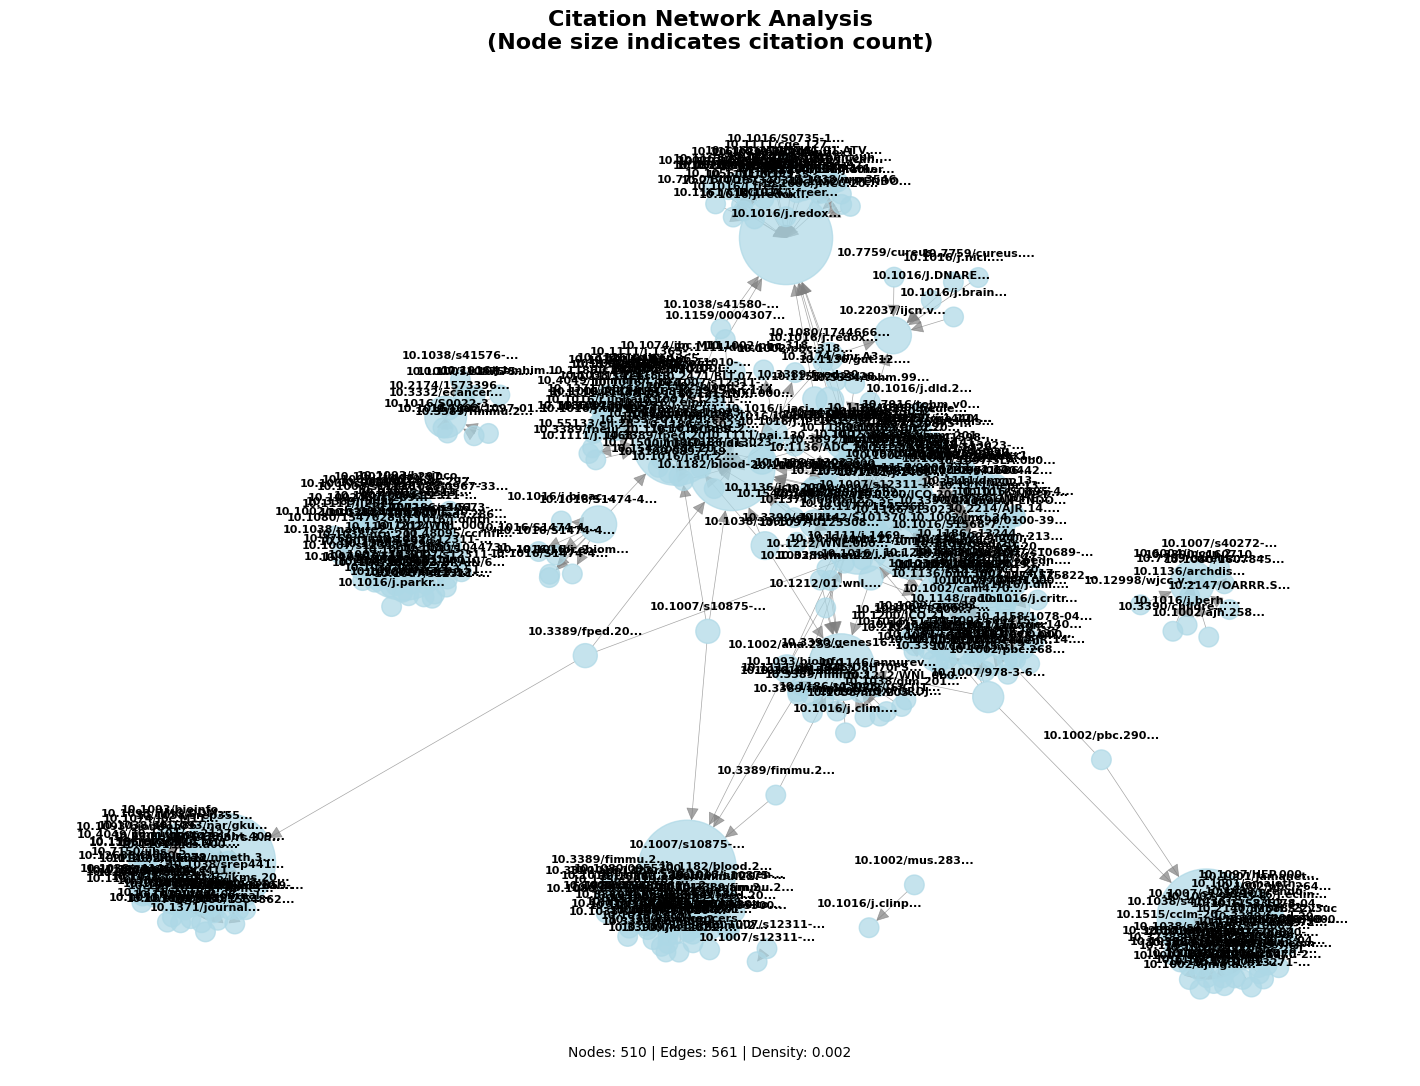

2025-07-07 23:06:38,310 - literature_search - INFO - 💾 Search results saved to search_results_20250707_230638.csv
INFO:literature_search:💾 Search results saved to search_results_20250707_230638.csv
2025-07-07 23:06:38,339 - literature_search - INFO - 💾 Screening results saved to screening_results_20250707_230638.csv
INFO:literature_search:💾 Screening results saved to screening_results_20250707_230638.csv
2025-07-07 23:06:38,343 - literature_search - INFO - 💾 Citation network saved to citation_network_20250707_230638.csv
INFO:literature_search:💾 Citation network saved to citation_network_20250707_230638.csv
2025-07-07 23:06:38,346 - literature_search - INFO - 💾 Network statistics saved to network_stats_20250707_230638.json
INFO:literature_search:💾 Network statistics saved to network_stats_20250707_230638.json
2025-07-07 23:06:38,347 - literature_search - INFO - ==================================================
INFO:literature_search:==================================================
20


📊 Step 6: Results Analysis
----------------------------------------

📊 LITERATURE SEARCH PIPELINE SUMMARY

📚 SEARCH RESULTS:
   Total papers found: 199
   Papers with DOI: 198
   Unique journals: 151

🔍 SCREENING RESULTS:
   Papers screened: 399
   FALSE: 318
   TRUE: 69
   POSSIBLE_NO_ABSTRACT: 12

   📋 Study types identified:
   narrative_review: 143
   other: 110
   case_series: 38
   observational: 33
   observational_study: 20
   case_report: 16
   basic science: 12
   randomised_trial: 7
   systematic_review: 5
   non_randomised_trial: 3
   basic_science: 2
   meeting_report: 1
   meta_analysis: 1
   laboratory_study: 1
   case-control_study: 1
   preclinical_study: 1
   cross-sectional: 1
   retrospective_analysis: 1
   phase_I_phase_II_trial: 1
   meta-analysis: 1
   prospective_cohort_study: 1

🕸️ CITATION NETWORK:
   Citation relationships: 563
   num_nodes: 510
   num_edges: 561
   density: 0.002
   is_connected: False
   avg_degree: 2.200
   max_degree: 54
   min_degree: 1

In [ ]:
# This runs the complete pipeline and then diagnoses it
results, pipeline = main_with_pipeline()